## Preparation

### Requirements

In [11]:
%pip install torchinfo torchvision opencv-python matplotlib kagglehub seaborn

Note: you may need to restart the kernel to use updated packages.


In [27]:
import utils
# import networks
import torch
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from plot_utils import plot_confmat, plot_gradcam
from grad_cam import GradCAM
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# %matplotlib inline
from torchinfo import summary
import kagglehub
import os
import shutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report



In [13]:
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15


BATCH_SIZE = 4

# we'll set up device used for training
device = utils.device
print(f"Using device: {device}")

Using device: cuda


### Dataset preparation

This step downloads the dataset from Kaggle, and prepares it to be used. It splits the dataset into training, validation, and test sets, and prepares the directory structure for the dataloaders:
 * `data/train/[class]`
 * `data/test/[class]`
 * `data/val/[class]`

#### Downloading

In [14]:
# https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
path = kagglehub.dataset_download("tawsifurrahman/tuberculosis-tb-chest-xray-dataset", output_dir="./data")

#### Splitting

In [15]:
def split_dataset(source_dir, output_dir, classes=("Normal", "Tuberculosis"),
                  train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):

    for split in ["train", "val", "test"]:
        for cls in classes:
            os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

    for cls in classes:
        class_dir = os.path.join(source_dir, cls)

        image_files = [f for f in os.listdir(class_dir) if f.lower().endswith((".png"))]

        train_files, temp_files = train_test_split(image_files, train_size=train_size, random_state=random_state,shuffle=True)
        val_relative_size = val_size / (val_size + test_size) # de les que queden, dividim segons split
        val_files, test_files = train_test_split(temp_files, train_size=val_relative_size, random_state=random_state, shuffle=True)

        # mètode per copiar d'un dir a un altre
        def copy_files(files, split):
            target_dir = os.path.join(output_dir, split, cls)
            for file in files:
                shutil.copy2(os.path.join(class_dir, file), os.path.join(target_dir, file))

        copy_files(train_files, "train")
        copy_files(val_files, "val")
        copy_files(test_files, "test")

source_dir = "./data/TB_Chest_Radiography_Database"

try:
    split_dataset(
        source_dir=source_dir,
        output_dir="./data",
        train_size=TRAIN_SPLIT,
        val_size=VAL_SPLIT,
        test_size=TEST_SPLIT,
    )

    # eliminem per espai
    shutil.rmtree(source_dir)
except Exception as e:
    print(f"Error occurred. Maybe the source directory does not exist, as data was already split into train/test/val splits: \n\t{e} ")

Error occurred. Maybe the source directory does not exist, as data was already split into train/test/val splits: 
	[Errno 2] No such file or directory: './data/TB_Chest_Radiography_Database/Normal' 


## Dataset analysis

The idea of this step is to load the dataset and analyze it. We will look at the class distribution, and some sample images for each class.

### Sample image ploting

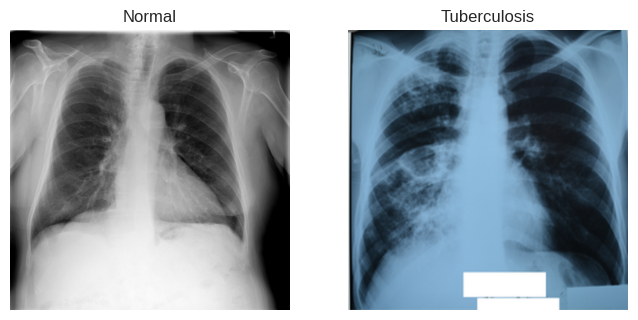

In [16]:
# Loading the data for visualization
test_set = datasets.ImageFolder(root=utils.dirs['test'], transform=transforms.ToTensor())
test_dl = torch.utils.data.DataLoader(test_set, batch_size=16, shuffle=True, num_workers=2)
images, labels = next(iter(test_dl)) # Load the first batch from the dataloader (size 16)

class_names = ['Normal', 'Tuberculosis']
class_samples = {class_name: None for class_name in class_names}

# Get a sample image for each one of the classes
for c in class_samples:
    idx_class = test_set.class_to_idx[c]
    idx_img = torch.where(labels == idx_class)[0][0].item()
    class_samples[c] = images[idx_img]
    
# Plot the samples
fig = plt.figure(figsize=(8, 8))
for i in np.arange(2):
    label = class_names[i]
    img = class_samples[label]
    ax = fig.add_subplot(2, 2, i+1)
    ax.axis('off')
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(label)
# fig.savefig('outputs/samples.png')

### Class distribution

Count for each class in the training set: {'Normal': 2450, 'Tuberculosis': 489}
Percentage for each class in the training set: {'Normal': 83.36, 'Tuberculosis': 16.64}%


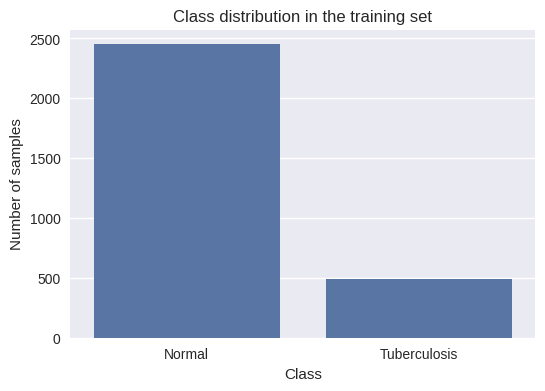

In [17]:
# plot class distribution in the training set
train_set = datasets.ImageFolder(root=utils.dirs['train'], transform=transforms.ToTensor())
train_dl = torch.utils.data.DataLoader(train_set, batch_size=16, shuffle=True, num_workers=2)
train_images, train_labels = next(iter(train_dl))
targets = train_set.targets
class_counts = [targets.count(i) for i in range(len(class_names))]
plt.figure(figsize=(6, 4))
sns.barplot(x=class_names, y=class_counts)
plt.title("Class distribution in the training set")
plt.ylabel("Number of samples")
plt.xlabel("Class")

print(f"Count for each class in the training set: {dict(zip(class_names, class_counts))}")
print(f"Percentage for each class in the training set: {dict(zip(class_names, [round(count / len(train_set) * 100, 2) for count in class_counts]))}%")

## Transfer learning

The idea of this step is to use two pretrained models (ResNet50 and EfficientNetB0) and fine-tune them on our dataset. We will then compare the results of the two models and choose the best one for the following steps.

### Helper methods

These methods are used to train and evaluate the models.

In [18]:
# prepare the train loader
train_set = datasets.ImageFolder(root=utils.dirs['train'], transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
train_images, train_labels = next(iter(train_loader))

# and the validation loader
val_set = datasets.ImageFolder(root=utils.dirs['val'], transform=transforms.ToTensor())
val_loader = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_images, val_labels = next(iter(val_loader))

In [19]:
import os
import csv
import torch


def train_model(model, train_loader, criterion, optimizer, num_epochs, save_path, val_loader=None, csv_path="training_stats.csv"):
    history = []

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0
        current = 0

        for images, labels in train_loader:
            current += images.size(0)

            print(f"Epoch {epoch+1}/{num_epochs} - Progress: {current}/{len(train_loader.dataset)}", end="\r")

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        val_loss = None
        val_acc = None

        if val_loader is not None:
            model.eval()

            val_running_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for images, labels in val_loader:
                    images = images.to(device)
                    labels = labels.to(device)

                    outputs = model(images)
                    loss = criterion(outputs, labels)

                    val_running_loss += loss.item()

                    _, predicted = torch.max(outputs, 1)

                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()

            val_loss = val_running_loss / len(val_loader)
            val_acc = val_correct / val_total

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc
        })

        if val_loader is not None:
            print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}")
        else:
            print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f}")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    torch.save(model.state_dict(), save_path)

    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["epoch", "train_loss", "train_accuracy", "val_loss", "val_accuracy"])
        writer.writeheader()
        writer.writerows(history)

    print(f"Model saved to {save_path}")
    print(f"Training statistics saved to {csv_path}")

    return history

In [ ]:
def evaluate_model(model, test_loader, test_set):
    test_preds = utils.get_all_preds(model, test_loader) # ja posa en eval
    _, predicted = torch.max(test_preds, dim=1) # escollim la classe amb probabilitat més alta
    y_true = torch.as_tensor(test_set.targets, device=device)

    print(classification_report(
        y_true.cpu(),
        predicted.cpu(),
        target_names=test_set.classes,
        digits=4,
        zero_division=0
    ))
    
    test_preds = test_preds.cpu()
    test_set.targets = torch.as_tensor(test_set.targets)

    test_confmat = utils.get_confmat(test_set, test_preds)

    plot_confmat(test_confmat, test_set.classes, f"{type(model).__name__.lower()}")

### ResNet18

In [ ]:
# load resnet18 and train it
# load resetnet18

# resnet18 = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
resnet18 = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
resnet18.fc = torch.nn.Linear(resnet18.fc.in_features, len(class_names))

summary(resnet18)
# we can see how resnet18 has nearly 25M parameters

resnet18.to(device)

Using cache found in /home/pol/.cache/torch/hub/pytorch_vision_v0.10.0
/home/pol/Downloads/AIH/Assignment/.env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/pol/Downloads/AIH/Assignment/.env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [ ]:
# criterion will be cross entropy loss since we have a classification problem
# optimizer will be Adam with a learning rate of 1e-4

import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    resnet18.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

NUM_EPOCHS = 2

train_model(resnet18, train_loader, criterion, optimizer, NUM_EPOCHS, "models/resnet18.pth", val_loader=val_loader, csv_path=f"stats_resnet18_{NUM_EPOCHS}epochs.csv")

Epoch [1/2] Train Loss: 0.0810 Train Acc: 0.9826 | Val Loss: 0.0154 Val Acc: 0.9968
Epoch [2/2] Train Loss: 0.0236 Train Acc: 0.9966 | Val Loss: 0.0117 Val Acc: 0.9968
Model saved to models/resnet50.pth
Training statistics saved to stats_resnet50_2epochs.csv


[{'epoch': 1,
  'train_loss': 0.08098369153251327,
  'train_accuracy': 0.9826471588975842,
  'val_loss': 0.01543976513107053,
  'val_accuracy': 0.9968253968253968},
 {'epoch': 2,
  'train_loss': 0.023564369074578973,
  'train_accuracy': 0.9965974821367812,
  'val_loss': 0.011747080688674262,
  'val_accuracy': 0.9968253968253968}]

### EfficientNetB0

In [21]:
# load efficientnetb0 and train it
efficientnet = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_efficientnet_b0', pretrained=True)

# per veure com és la part de classificiació i veure quants inputs ha de tenir l'última capa per adaptar-la
# print(efficientnet.classifier) # veiem que té una última linear de 1000 outputs i 1280 inputs
efficientnet.classifier[-1] = torch.nn.Linear(efficientnet.classifier[-1].in_features, len(class_names))

summary(efficientnet)
efficientnet.to(device)

Using cache found in /home/pol/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub
/home/pol/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/pol/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(


EfficientNet(
  (stem): Sequential(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, bias=True, track_running_stats=True)
    (activation): SiLU(inplace=True)
  )
  (layers): Sequential(
    (0): Sequential(
      (block0): MBConvBlock(
        (depsep): Sequential(
          (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, bias=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (se): SequentialSqueezeAndExcitation(
          (squeeze): Linear(in_features=32, out_features=8, bias=True)
          (expand): Linear(in_features=8, out_features=32, bias=True)
          (activation): SiLU(inplace=True)
          (sigmoid): Sigmoid()
          (mul_a_quantizer): Identity()
          (mul_b_quantizer): Ident

In [22]:
# criterion will be cross entropy loss since we have a classification problem
# optimizer will be Adam with a learning rate of 1e-4

from sympy import N
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    efficientnet.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

NUM_EPOCHS = 2

train_model(efficientnet, train_loader, criterion, optimizer, NUM_EPOCHS, "models/efficientnet.pth", val_loader=val_loader, csv_path=f"stats_efficientnet_{NUM_EPOCHS}epochs.csv")

Epoch [1/2] Train Loss: 0.1356 Train Acc: 0.9799 | Val Loss: 0.0085 Val Acc: 0.9984
Epoch [2/2] Train Loss: 0.0255 Train Acc: 0.9963 | Val Loss: 0.0108 Val Acc: 1.0000
Model saved to models/efficientnet.pth
Training statistics saved to stats_efficientnet_2epochs.csv


[{'epoch': 1,
  'train_loss': 0.13555869658091138,
  'train_accuracy': 0.9799251446070092,
  'val_loss': 0.008509313854338422,
  'val_accuracy': 0.9984126984126984},
 {'epoch': 2,
  'train_loss': 0.0254681419243808,
  'train_accuracy': 0.9962572303504593,
  'val_loss': 0.010800536952196632,
  'val_accuracy': 1.0}]

### Evaluation

              precision    recall  f1-score   support

      Normal     0.8343    0.8343    0.8343       525
Tuberculosis     0.1792    0.1792    0.1792       106

    accuracy                         0.7242       631
   macro avg     0.5068    0.5068    0.5068       631
weighted avg     0.7242    0.7242    0.7242       631

Test Accuracy: 0.7242


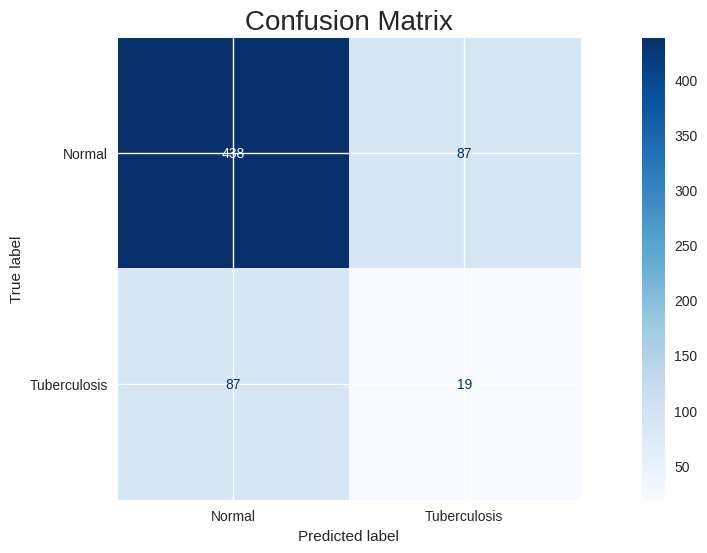

In [ ]:
evaluate_model(resnet18, test_dl, test_set)

              precision    recall  f1-score   support

      Normal     0.8400    0.8400    0.8400       525
Tuberculosis     0.2075    0.2075    0.2075       106

    accuracy                         0.7338       631
   macro avg     0.5238    0.5238    0.5238       631
weighted avg     0.7338    0.7338    0.7338       631

Test Accuracy: 0.7338


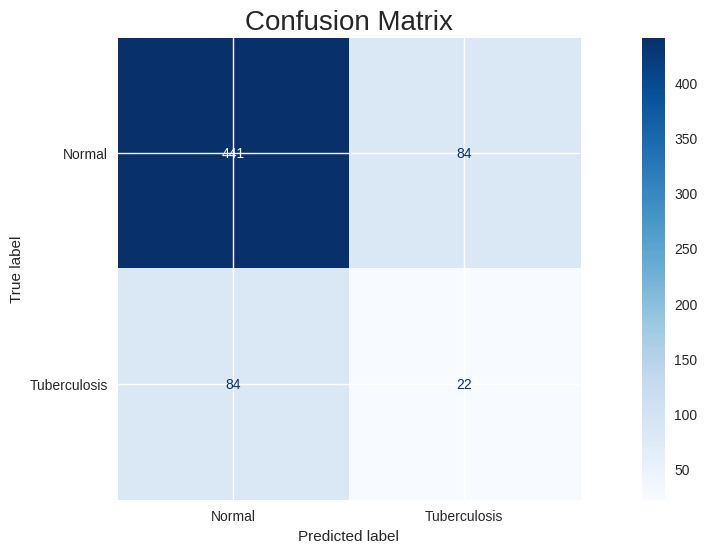

In [35]:
evaluate_model(efficientnet, test_dl, test_set)

One important metric we should be considering is recall, since we want to minimize the number of false negatives (patients with tuberculosis that are not detected). Looking at it, it can be seen how neither of the two models is performing well, with recall values lower than 0.25. If we had only focused on accuracy, we would have been misled thinking the models were performing somewhat well (right around 75% of the times).

Both models have a tendency to predict the negative class (no tuberculosis) more often. This could be expected, as it was seen how the dataset is imbalanced, with more negative samples than positive ones. 

With this short training, the EfficientNetB0 model is performing slightly better than the ResNet18 model, with a recall of 0.20 compared to 0.17, and a slightly better precision and overall accuracy. Also taking into account the amount of parameters of each model, and thus the computational cost, we can conclude that EfficientNetB0 is the best model for our task. For the following steps, we'll be using this model as the base model.

## Imbalance comparison

This step will compare the performance of the model with different imbalance techniques:
* No correction (dataset as it is)
* Oversampling
* Undersampling
* Class weights
* Data augmentation

This idea is to discover which technique works best for our dataset, and if it is worth applying any of them. As mentioned, the model we will be using for this comparison is the EfficientNetB0, as it was the best performing model in the previous step.

## Hyperparameter tuning

## Evaluation

## Explainability